<a href="https://colab.research.google.com/github/Adedayo-py/SWEP-project-PTIE/blob/main/Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

In [6]:
df_titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

##### This displays the first rows of the dataset to help us understand:
##### the column name
##### the type of information stored,
##### and the general structure of the dataset

In [7]:
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df_titanic.shape

(891, 12)

In [9]:
df_titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

## This displays all column in the dataset.

In [10]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [14]:
df_titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Analysis
##### The cabin column has too many missing values and may not be very useful for analysis

##### Missing values in Age may affect statistical analysis and machine learning models.

##### Missing valeus must be handled before advanced modelling

In [15]:
df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
df_titanic['Survived'].value_counts()

,count
Survived,
0,549
1,342


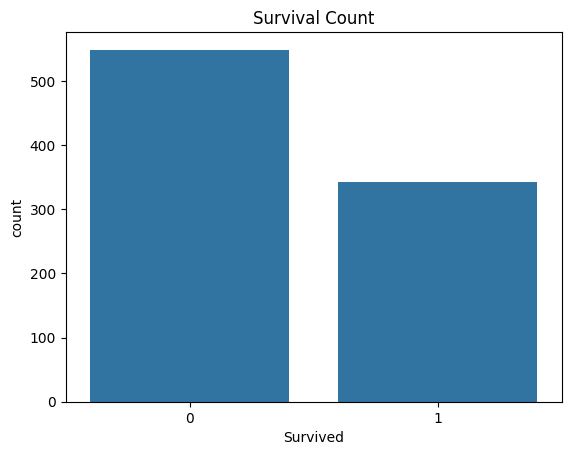

In [18]:
sns.countplot(x='Survived', data=df_titanic)
plt.title('Survival Count')
plt.show()

# survival by gender

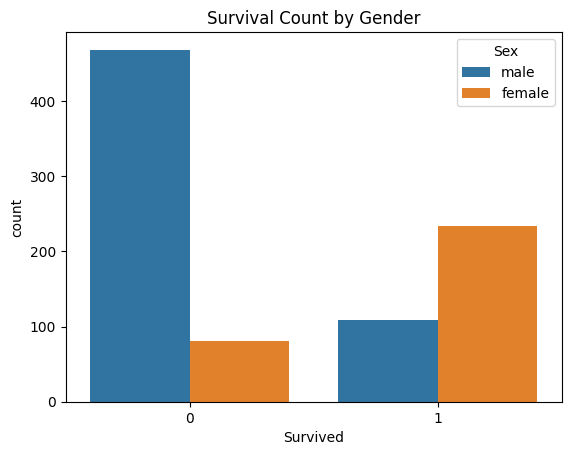

In [19]:
sns.countplot(x='Survived', hue='Sex', data=df_titanic)
plt.title('Survival Count by Gender')
plt.show()

## Analysis
##### females had a significantly higher survival rate than males.
##### Most male passengers did nit survive
##### this suggest the 'women first' evacuation strategy was followed.

## insight
##### Gender strongly influenced survival chances

# survival by passenger class

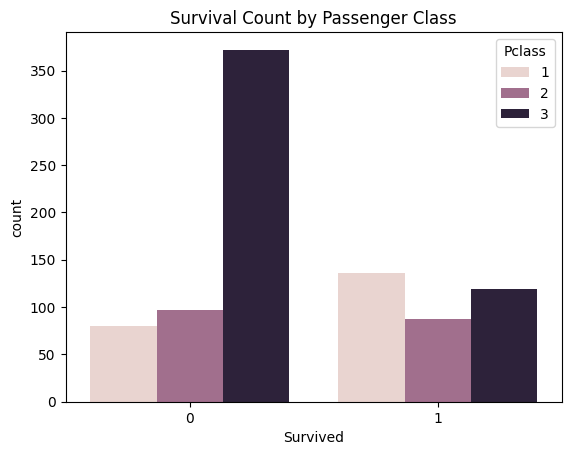

In [20]:
sns.countplot(x='Survived', hue='Pclass', data=df_titanic)
plt.title('Survival Count by Passenger Class')
plt.show()

## Analysis
##### First class passengers had the highest survival rate.
##### Third class passengers had the lowest survaival rate.

## Insight
##### socioeconomic ststus may hav influenced access to lfeboats amd rescue opportunities

# Age distribution

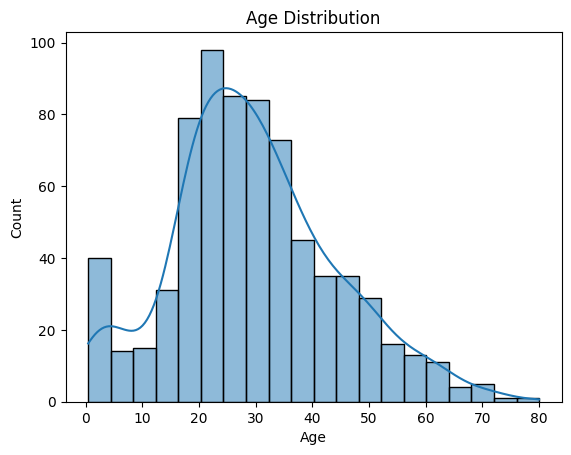

In [27]:
sns.histplot(df_titanic['Age'], kde=True)
plt.title('Age Distribution')
plt.show()

## Analysis
##### Most passenger were between ages 20 and 40
##### Few elderly passengers were onboard
##### Some children were also present

## Insight
##### The dataset mainly represents young and middle_aged adults

# Correlation Matrix

In [28]:
numeric_df_titanic = df_titanic.select_dtypes(include=['number'])
correlation_matrix = numeric_df_titanic.corr()

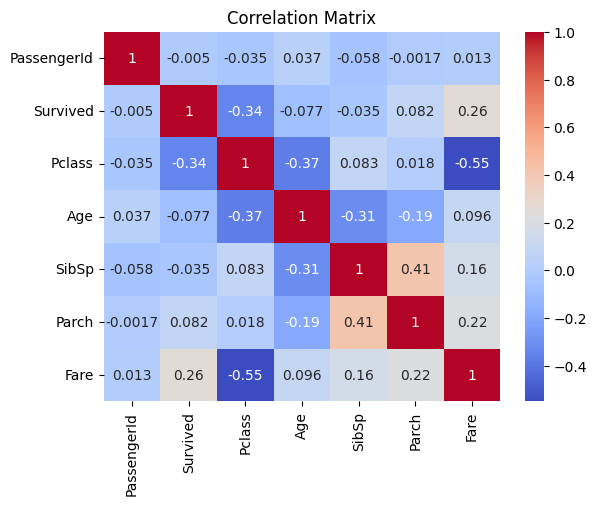

In [31]:
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Analysis
##### Passenger class negatively correlates with survival.
###### lower class number(1st class) had better survival chances.
##### Fare positively correlates with survival.
###### Higher-paying passengers survived more often

## Insight
##### Economic status appears related to survival probablity

# Detect Outliers

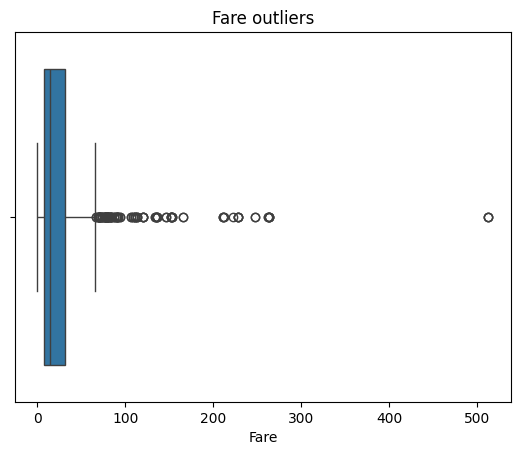

In [32]:
sns.boxplot(x=df_titanic['Fare'])
plt.title('Fare outliers')
plt.show()

## Analysis
##### Several extreme outliers exist in the fare column.
##### Some passengers paid unusually expensive ticket prices.

## Insight
##### Outliers may affect statistical measures like the mean

# Embarkation Analysis

In [33]:
df_titanic['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


## Analysis
##### Most passsenger boarded from:
##### Southampton(s) followed by:
##### Cherbourg(c)
##### Queenstown(Q)

## Family size Analysis

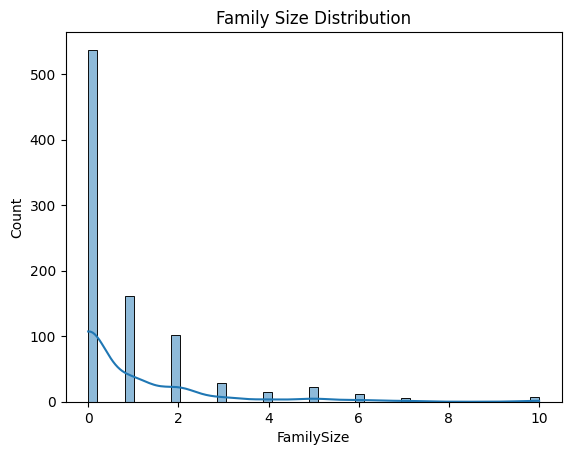

In [34]:
df_titanic['FamilySize'] = df_titanic['SibSp'] + df_titanic['Parch']

sns.histplot(df_titanic['FamilySize'], kde=True)
plt.title('Family Size Distribution')
plt.show()

## Analysis
##### Most passenger traveled alone.
##### Some traveled with family members.

## Insight
##### Family size may influence survival chances.

## Conclusion
##### The Exploratory Data Analysis revealed important patterns in the Titanic dataset. Survival was heavily influeced by factors such as gender, passenger class, and fare paid. females and first-class passengers had better survival chances compared to males and third-class passengers.